<a href="https://colab.research.google.com/github/akshat280706/ML-Lab-Experiment/blob/main/241080009_akshat_ML_Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving mushrooms.csv to mushrooms.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

df=pd.read_csv("mushrooms.csv")
print("datashape: ", df.shape)

X = df.drop("class", axis=1)
y = df["class"]

#encoding
y = y.map({"e": 0,"p": 1}).values
X=pd.get_dummies(X,dtype=float).values.astype(np.float64)
print("encoded dshape:", X.shape)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42
                                               ,stratify=y)
#representation each into columns
X_train=X_train.T
X_test=X_test.T
y_train = y_train.reshape(1,-1)
y_test = y_test.reshape(1,-1)


datashape:  (8124, 23)
encoded dshape: (8124, 117)


epoch:  0 loss: 0.698207
epoch:  100 loss: 0.449824
epoch:  200 loss: 0.292795
epoch:  300 loss: 0.209492
epoch:  400 loss: 0.159931

accuracy:  97.42 %

confusion matrix: 
[[828  14]
 [ 28 755]]
Precision: 0.98
Recall: 0.96
F1Score: 0.97


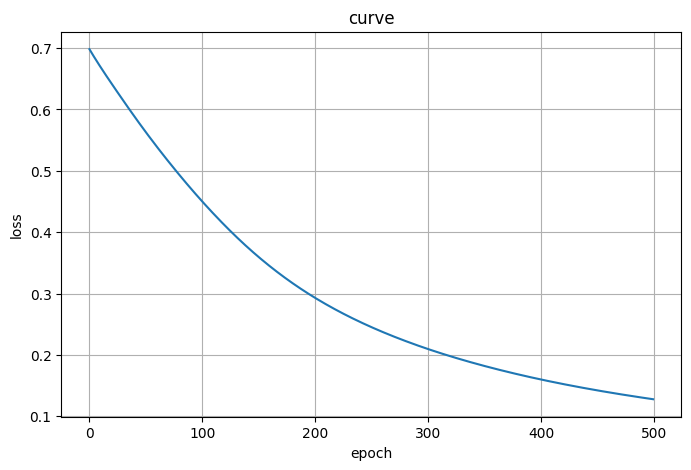


lib acc 100.0 %

lib confusion matrix: 
[[842   0]
 [  0 783]]


In [6]:
from inspect import Parameter
#activationfnxs
def relu(Z):
  return np.maximum(0,Z)
def relu_derivative(Z):
  return (Z>0).astype(float)

def sigmoid(Z):
  Z=np.clip(Z,-500,500)
  return 1/(1+np.exp(-Z))

def initialize_parameters(input_size,hidden1_size,hidden2_size,output_size):
  np.random.seed(42)

  #applying he initialization(root(2/no of i/p))
  w1=np.random.randn(hidden1_size,input_size)*np.sqrt(2/input_size)
  b1=np.zeros((hidden1_size,1))
  w2=np.random.randn(hidden2_size,hidden1_size)*np.sqrt(2/hidden1_size)
  b2=np.zeros((hidden2_size,1))
  w3=np.random.randn(output_size,hidden2_size)*np.sqrt(2/hidden2_size)
  b3=np.zeros((output_size,1))

  return{"w1":w1, "b1":b1,"w2":w2, "b2":b2,"w3":w3, "b3":b3}

#forward propogation
def forward_propogation(X,parameters):
  w1=parameters["w1"]
  b1=parameters["b1"]

  w2=parameters["w2"]
  b2=parameters["b2"]

  w3=parameters["w3"]
  b3=parameters["b3"]

  Z1=np.dot(w1,X)+b1
  A1=relu(Z1)
  Z2=np.dot(w2,A1)+b2
  A2=relu(Z2)
  Z3=np.dot(w3,A2)+b3
  A3=sigmoid(Z3)

  vals = {"Z1":Z1,"A1":A1,"Z2":Z2,"A2":A2,"Z3":Z3,"A3":A3}
  return A3,vals

#loss fxn
#comparing actual y with predicted
def compute_loss(Y,AL):
  m=Y.shape[1] #no. training ex
  AL= np.clip(AL, 1e-8,1-1e-8) #else log(0)
  loss=-(1/m)*np.sum(Y*np.log(AL)+(1-Y)*np.log(1-AL))
  return loss

#backpropogation(how much should each wt and bias change)
def backward_propogation(X,Y,parameters,vars):
  m=X.shape[1]
  w2 = parameters["w2"] #for layer1
  w3 = parameters["w3"] #for layer2
  Z1=vars["Z1"]
  A1=vars["A1"]
  Z2=vars["Z2"]
  A2=vars["A2"]
  A3=vars["A3"]

  #output layer
  dZ3=A3-Y
  dw3=(1/m)*np.dot(dZ3,A2.T)
  db3=(1/m)*np.sum(dZ3,axis=1,keepdims=True)

  #hidden layer2
  dA2=np.dot(w3.T,dZ3)
  dZ2=dA2*relu_derivative(Z2)
  dw2=(1/m)*np.dot(dZ2,A1.T)
  db2=(1/m)*np.sum(dZ2,axis=1,keepdims=True)

  #hidden layer1
  dA1=np.dot(w2.T,dZ2)
  dZ1=dA1*relu_derivative(Z1)
  dw1=(1/m)*np.dot(dZ1,X.T)
  db1=(1/m)*np.sum(dZ1,axis=1,keepdims=True)

  return {"dw1":dw1,"db1":db1,"dw2":dw2,"db2":db2,"dw3":dw3,"db3":db3}

#updating parameters
def update_parameters(parameters,gradients,learning_rate):
  parameters["w1"]-=(learning_rate*gradients["dw1"])
  parameters["b1"]-=(learning_rate*gradients["db1"])
  parameters["w2"]-=(learning_rate*gradients["dw2"])
  parameters["b2"]-=(learning_rate*gradients["db2"])
  parameters["w3"]-=(learning_rate*gradients["dw3"])
  parameters["b3"]-=(learning_rate*gradients["db3"])
  return parameters

def train_neural_network(X,Y,hidden1_size=64,hidden2_size=32,learning_rate=0.01,
                         epochs=500):
  input_size=X.shape[0]
  parameters=initialize_parameters(input_size,hidden1_size,hidden2_size,1)
  losses=[]
  for epoch in range(epochs):
    #forward prop
    AL,vars=forward_propogation(X,parameters)
    #loss
    loss=compute_loss(Y,AL)
    #backward prop
    gradients=backward_propogation(X,Y,parameters,vars)
    #update
    parameters=update_parameters(parameters,gradients,learning_rate)
    losses.append(loss)
    if epoch%100==0: #printing each 100 epochs
      print("epoch: ",epoch,"loss:",round(loss,6))

  return parameters,losses

#calling above fxn
parameters,losses=train_neural_network(X_train,y_train,hidden1_size=64,
                                          hidden2_size=32,learning_rate=0.01,
                                          epochs=500)

#predictions
def predict(X,parameters):
  AL,_=forward_propogation(X,parameters)
  return (AL >= 0.5).astype(int)

y_pred_nn=predict(X_test,parameters)

#accuracy
accuracy_nn=np.mean(y_pred_nn==y_test)*100
print("\naccuracy: ",round(accuracy_nn,2),"%")

#confusion matrix
print("\nconfusion matrix: ")
print(confusion_matrix(y_test.flatten(),y_pred_nn.flatten()))

precision_nn=precision_score(y_test.flatten(),y_pred_nn.flatten())
recall_nn=recall_score(y_test.flatten(),y_pred_nn.flatten())
f1_nn=f1_score(y_test.flatten(),y_pred_nn.flatten())
print("Precision:",round(precision_nn,2))
print("Recall:",round(recall_nn,2))
print("F1Score:",round(f1_nn,2))


#graph
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("curve")
plt.grid(True)
plt.show()


#library
X_train_tree = X_train.T
X_test_tree = X_test.T
y_train_tree = y_train.flatten()
y_test_tree = y_test.flatten()

tree_model = DecisionTreeClassifier(criterion="entropy",random_state=42)
tree_model.fit(X_train_tree,y_train_tree)
y_pred_tree = tree_model.predict(X_test_tree)
accuracy_tree = accuracy_score(y_test_tree,y_pred_tree)*100
print("\nlib acc",round(accuracy_tree, 2),"%")
print("\nlib confusion matrix: ")
print(confusion_matrix(y_test_tree,y_pred_tree))
